# TesTEA - Evaluación y Comparativa de Modelos Predictivos
En este notebook se ejecuta la fase de evaluación y comparación de modelos de Machine Learning para la detección de TEA:

*   adults
*   combined
*   toddlers
*   adolescents

El objetivo es analizar el rendimiento de los algoritmos entrenados y determinar cuál identifica mejor los casos positivos, aplicando:

*   Carga de los conjuntos de datos de prueba previamente procesados.
*   Evaluación comparativa de cuatro tipos de algoritmos: Baseline, Regresión Logística, Random Forest y XGBoost.
*   Generación de matrices de confusión visuales para analizar falsos positivos y falsos negativos.
*   Construcción de una tabla resumen con métricas clave de clasificación.
*   Optimización y priorización del recall (sensibilidad) para minimizar la pérdida de casos positivos reales.


## **1. Importaciones y Carga de Datos**
Preparación del entorno y carga de los conjuntos de prueba:

*   *Librerías del sistema:* Carga de herramientas esenciales para analítica (pandas, numpy), gráficos (matplotlib, seaborn) y deserialización de modelos (joblib).

*   *Módulos locales:* Integración de funciones personalizadas (calculate_metrics y plot_confusion_matrix) desde src.evaluate para estandarizar las métricas.

*   *Datasets de prueba:* Lectura automatizada desde data/processed de los archivos finales de prueba: adults_test.csv, toddlers_test.csv, adolescents_test.csv, combined_test.csv





In [23]:
import sys
from pathlib import Path

# CAMBIO: se anade la raiz del proyecto al sys.path, igual que hacen los
# notebooks 02 y 03. Sin esto, "from src.evaluate import ..." falla con
# ModuleNotFoundError en cuanto se ejecuta en un kernel nuevo, porque src/
# no esta en el path de Python por defecto al lanzar el notebook desde
# notebooks/.
PROJECT_ROOT = Path().resolve().parents[0]
sys.path.append(str(PROJECT_ROOT))

import os
import shap
import joblib
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, auc
from src.evaluate import (
    calculate_metrics,
    plot_confusion_matrix,
    plot_comparative_roc_curve
)

# Rutas corregidas con "../" para que funcionen ejecutando el notebook
# desde la carpeta notebooks/ (igual que 01, 02 y 03).
DATA_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"

# Carga de los archivos CSV procesados
df_adults_test = pd.read_csv(DATA_DIR / "adults_test.csv")
df_toddlers_test = pd.read_csv(DATA_DIR / "toddlers_test.csv")
df_adolescents_test = pd.read_csv(DATA_DIR / "adolescents_test.csv")
df_combined_test = pd.read_csv(DATA_DIR / "combined_test.csv")

# Configuración estética de las gráficas
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 14
})

print("Datasets cargados correctamente en memoria.")
print("PROJECT_ROOT:", PROJECT_ROOT)


Datasets cargados correctamente en memoria.
PROJECT_ROOT: C:\Users\adria\Documents\bootcamp\tesTEA


 ## **2. Evaluación por Grupos de Edad**
 Núcleo de evaluación cruzada entre los subgrupos de edad y los algoritmos entrenados:

*   *Mapeo estructurado:* Carga de forma masiva los cuatro conjuntos de datos de prueba (Adults, Toddlers, Adolescents y Combined) en un diccionario indexado para optimizar el acceso en memoria.

*   *Evaluación iterativa:* Recorre cada una de las familias de algoritmos analizando las predicciones individuales de cada modelo (Baseline, Regresión Logística, Random Forest y XGBoost).

*   *Diagnóstico visual (2x2):* Genera lienzos integrados de gráficos con matrices de confusión automatizadas por cada algoritmo para contrastar visualmente los aciertos, falsos positivos y falsos negativos.

*   *Consolidación de métricas:* Almacena el rendimiento estadístico calculado y exporta una tabla resumen final ordenada por la métrica de recall para identificar el modelo óptimo de cribado.






📊 Generando gráfica comparativa para la familia: Baseline


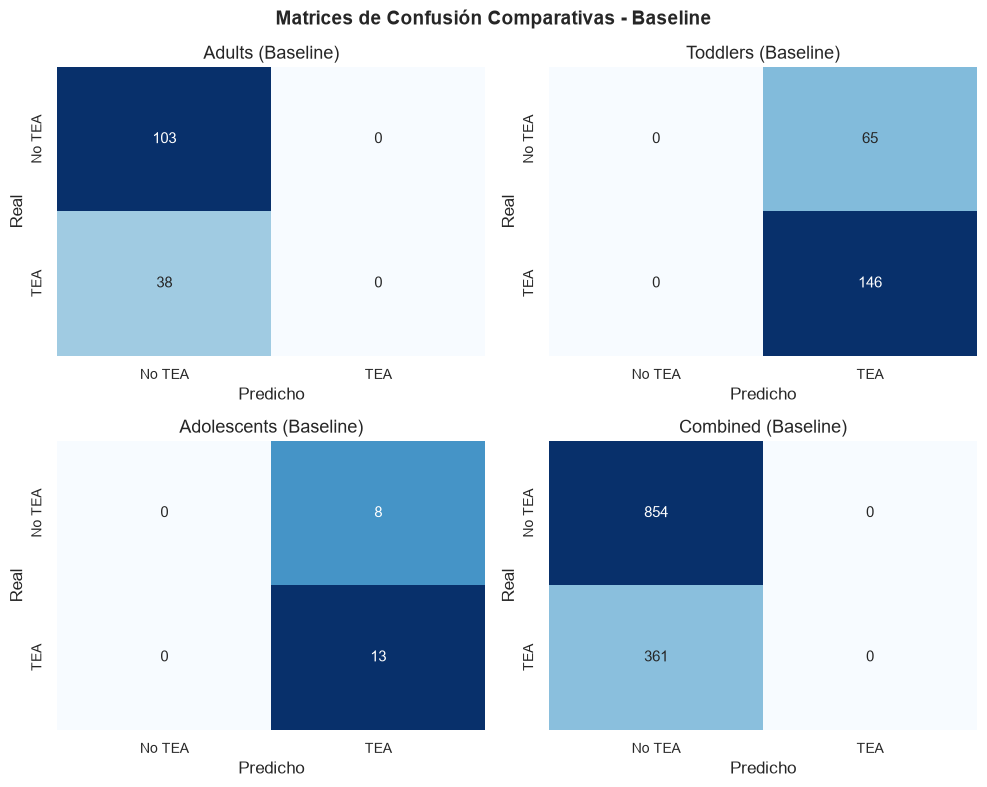


📊 Generando gráfica comparativa para la familia: Regresion_Logistica


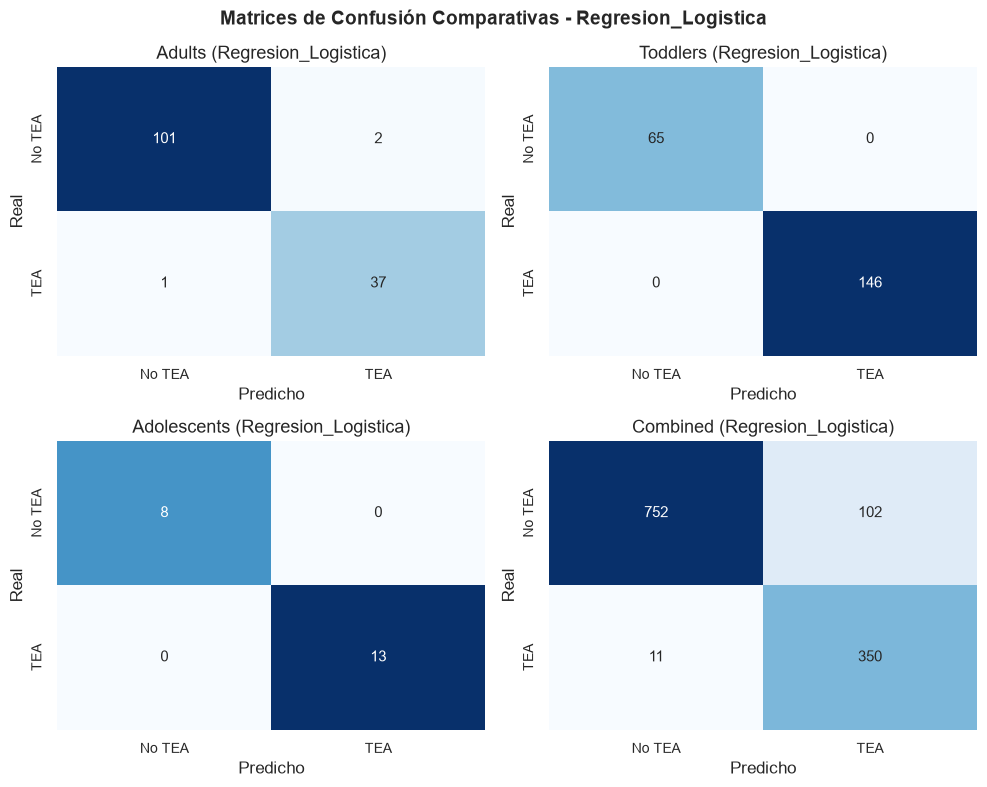


📊 Generando gráfica comparativa para la familia: Random_Forest


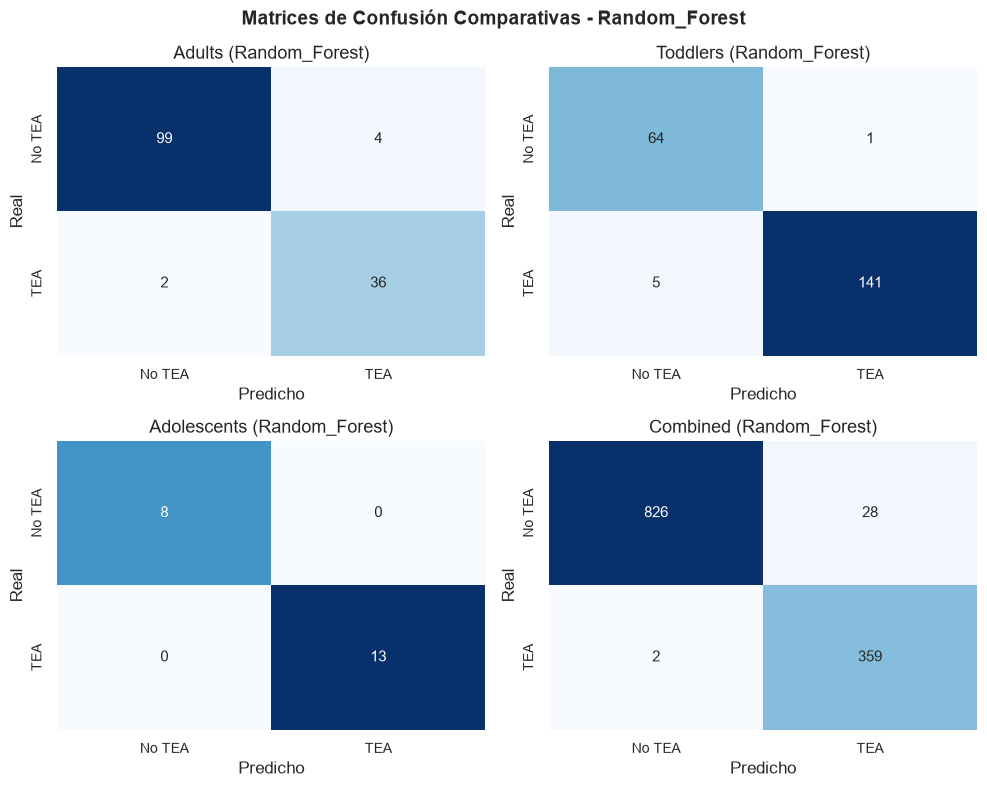


📊 Generando gráfica comparativa para la familia: XGBoost


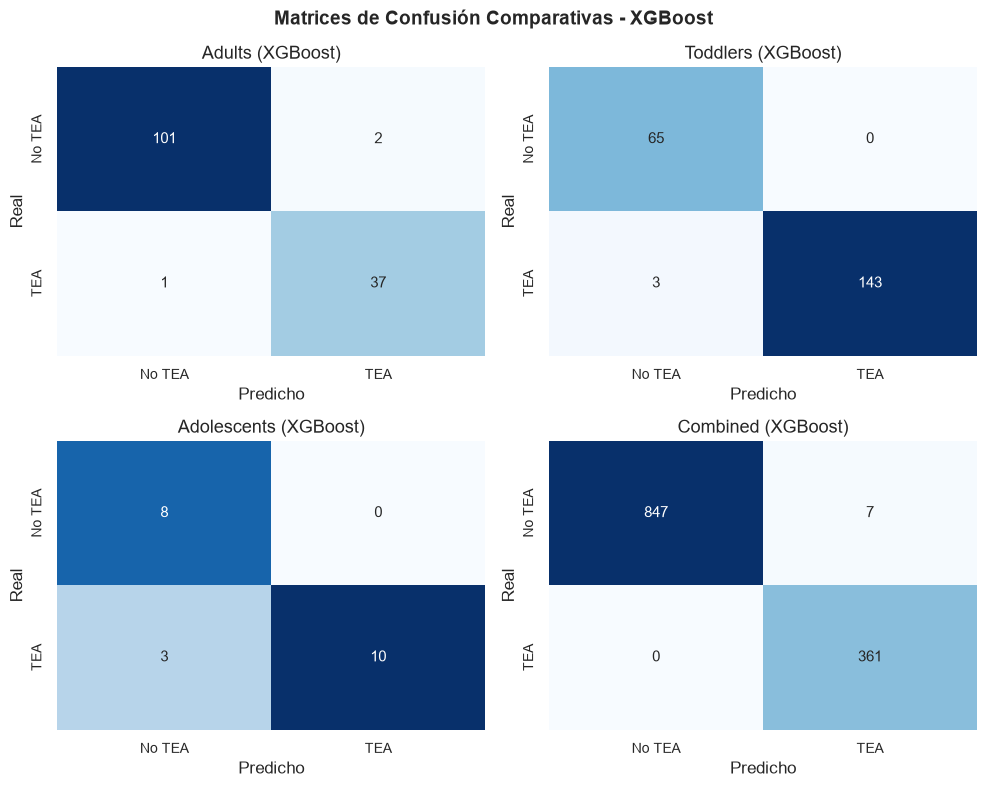


RESUMEN COMPARATIVO DE RENDIMIENTO


accuracy  precision    recall        f1  \
Grupo       Modelo                                                         
Toddlers    Baseline             0.691943   0.691943  1.000000  0.817927   
Adolescents Baseline             0.619048   0.619048  1.000000  0.764706   
            Regresion_Logistica  1.000000   1.000000  1.000000  1.000000   
Toddlers    Regresion_Logistica  1.000000   1.000000  1.000000  1.000000   
Combined    XGBoost              0.994239   0.980978  1.000000  0.990398   
Adolescents Random_Forest        1.000000   1.000000  1.000000  1.000000   
Combined    Random_Forest        0.975309   0.927649  0.994460  0.959893   
Toddlers    XGBoost              0.985782   1.000000  0.979452  0.989619   
Adults      XGBoost              0.978723   0.948718  0.973684  0.961039   
            Regresion_Logistica  0.978723   0.948718  0.973684  0.961039   
Combined    Regresion_Logistica  0.906996   0.774336  0.969529  0.861009   
Toddlers    Random_Forest        0.971564   0.992958  0.965753  0.979167   
Adults      Random_Forest        0.957447   0.900000  0.947368  0.923077   
Adolescents XGBoost              0.857143   1.000000  0.769231  0.869565   
Adults      Baseline             0.730496   0.000000  0.000000  0.000000   
Combined    Baseline             0.702881   0.000000  0.000000  0.000000   

                                  auc_roc  
Grupo       Modelo                         
Toddlers    Baseline             0.500000  
Adolescents Baseline             0.500000  
            Regresion_Logistica  1.000000  
Toddlers    Regresion_Logistica  1.000000  
Combined    XGBoost              1.000000  
Adolescents Random_Forest        1.000000  
Combined    Random_Forest        0.998547  
Toddlers    XGBoost              0.999789  
Adults      XGBoost              0.999234  
            Regresion_Logistica  0.998467  
Combined    Regresion_Logistica  0.955260  
Toddlers    Random_Forest        0.995258  
Adults      Random_Forest        0.986970  
Adolescents XGBoost              1.000000  
Adults      Baseline             0.500000  
Combined    Baseline             0.500000

In [24]:
# Definición de los grupos y algoritmos a evaluar
grupos = ["Adults", "Toddlers", "Adolescents", "Combined"]
algoritmos = ["Baseline", "Regresion_Logistica", "Random_Forest", "XGBoost"]

# Cargar los datasets en un diccionario para acceso rápido
datasets = {g: pd.read_csv(DATA_DIR / f"{g.lower()}_test.csv") for g in grupos}
resultados_globales = []

# Iterar por cada una de las 4 familias de algoritmos
for algoritmo in algoritmos:
    print(f"\n{'='*60}")
    print(f"📊 Generando gráfica comparativa para la familia: {algoritmo}")
    print(f"{'='*60}")

    # Creación de lienzo de 2x2 para meter los 4 grupos de edad en la misma imagen
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    axes = axes.flatten()

    for i, grupo in enumerate(grupos):
        df_test = datasets[grupo]
        X_test = df_test.drop(columns=["target"])
        y_test = df_test["target"].astype(int)

        archivo_modelo = MODELS_DIR / f"{grupo.lower()}_{algoritmo.replace('_', ' ')}.pkl"  # CAMBIO: los archivos reales usan espacio, no guion bajo
        ax = axes[i]

        if not archivo_modelo.exists():
            ax.text(0.5, 0.5, f"Archivo no encontrado:\n{archivo_modelo.name}",
                    ha='center', va='center', color='red')
            ax.axis('off')
            continue

        # Cargar y predecir
        modelo = joblib.load(archivo_modelo)
        y_pred = modelo.predict(X_test)
        y_proba = modelo.predict_proba(X_test)[:, 1] if hasattr(modelo, "predict_proba") else np.zeros(len(y_test))

        # Guardar métricas en la lista global
        met = calculate_metrics(y_test, y_pred, y_proba)
        met["Grupo"] = grupo
        met["Modelo"] = algoritmo
        resultados_globales.append(met)

        # Dibujar la matriz de confusión en su respectivo cuadrante (sub-plot)
        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                    xticklabels=["No TEA", "TEA"], yticklabels=["No TEA", "TEA"])
        ax.set_title(f"{grupo} ({algoritmo})")
        ax.set_ylabel("Real")
        ax.set_xlabel("Predicho")

    plt.suptitle(f"Matrices de Confusión Comparativas - {algoritmo}", fontsize=14, weight='bold')
    plt.tight_layout()
    plt.show() # Muestra la gráfica combinada (1 de 4)

# --- TABLA COMPARATIVA FINAL ---
print(f"\n{'='*60}\nRESUMEN COMPARATIVO DE RENDIMIENTO\n{'='*60}")
if resultados_globales:
    df_resultados = pd.DataFrame(resultados_globales).set_index(["Grupo", "Modelo"])
    display(df_resultados.sort_values(by="recall", ascending=False))

### **Conclusiones Clave**

*   *Modelos Perfectos:* Regresión Logística (en Adolescents y Toddlers) y Random Forest (en Adolescents) logran un 100% de acierto ($1.0$ en todas las métricas) sin fallar una sola predicción.

*   *El Mejor para Cribado Global (Combined):* XGBoost es el líder indiscutible en el dataset combinado con un 100% de recall (cero falsos negativos) y un $99.42\%$ de accuracy.

*   *Mejor Opción en Adultos:* XGBoost y Regresión Logística empatan como las mejores alternativas, alcanzando un excelente 97.36% de recall (solo 1 falso negativo).

*   *Descarte del Baseline:* El modelo base es inviable para uso médico; se limita a predecir la clase mayoritaria, dejando sin detectar al 100% de los adultos con TEA o disparando los falsos positivos.





## **3. Identificación Y Gráfico del Mejor Modelo**


🏆 SELECCIÓN DE LOS MEJORES MODELOS (MAX RECALL)


,accuracy,precision,recall,f1,auc_roc,Grupo,Modelo
6,1.000000,1.000000,1.000000,1.000000,1.000000,Adolescents,Regresion_Logistica
15,0.994239,0.980978,1.000000,0.990398,1.000000,Combined,XGBoost
5,1.000000,1.000000,1.000000,1.000000,1.000000,Toddlers,Regresion_Logistica
4,0.978723,0.948718,0.973684,0.961039,0.998467,Adults,Regresion_Logistica


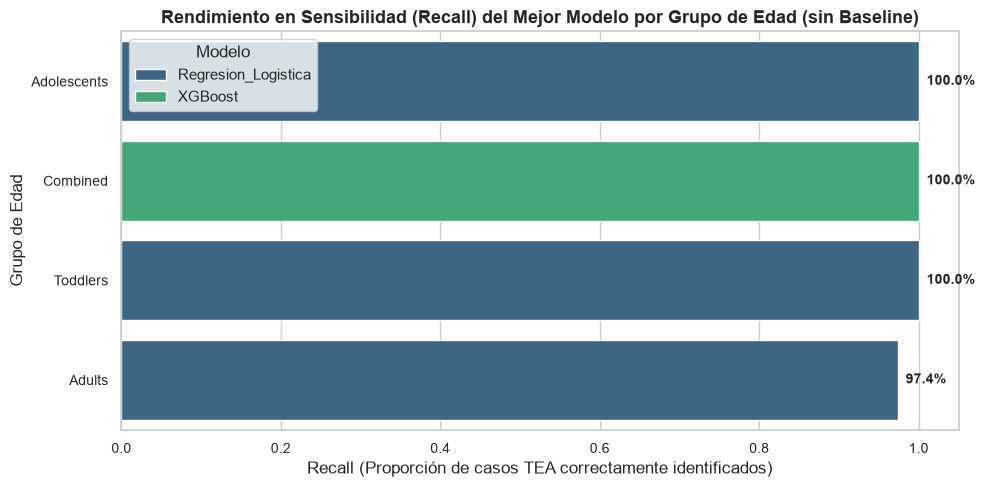


Mejor modelo por grupo (sin Baseline): {'Adolescents': 'Regresion_Logistica', 'Combined': 'XGBoost', 'Toddlers': 'Regresion_Logistica', 'Adults': 'Regresion_Logistica'}


In [25]:
print(f"\n{'='*60}\n🏆 SELECCIÓN DE LOS MEJORES MODELOS (MAX RECALL)\n{'='*60}")

# CAMBIO: se excluye el Baseline ANTES de buscar el maximo recall. El
# Baseline es solo la referencia minima (predice siempre la clase
# mayoritaria); en Adolescents y Toddlers puede alcanzar recall=1.0 sin
# haber aprendido nada, y no debe poder "ganar" la comparativa.
mejores_modelos = []

if resultados_globales:
    df_res_flat = pd.DataFrame(resultados_globales)
    df_res_sin_baseline = df_res_flat[df_res_flat["Modelo"] != "Baseline"]

    # Recall como criterio principal, f1 como desempate en caso de empate
    df_mejores = (
        df_res_sin_baseline
        .sort_values(["Grupo", "recall", "f1"], ascending=[True, False, False])
        .groupby("Grupo")
        .head(1)
        .sort_values(by="recall", ascending=False)
    )
    display(df_mejores)

    # Gráfico de barras comparativo
    plt.figure(figsize=(10, 5))
    ax = sns.barplot(x="recall", y="Grupo", hue="Modelo", data=df_mejores, palette="viridis")
    plt.title("Rendimiento en Sensibilidad (Recall) del Mejor Modelo por Grupo de Edad (sin Baseline)", weight='bold')
    plt.xlabel("Recall (Proporción de casos TEA correctamente identificados)")
    plt.ylabel("Grupo de Edad")
    plt.xlim(0, 1.05)

    # Añadir etiquetas de porcentaje en las barras
    for p in ax.patches:
        width = p.get_width()
        if width > 0:
            ax.text(width + 0.01, p.get_y() + p.get_height()/2, f'{width:.1%}',
                    ha="left", va="center", fontsize=10, weight='bold')
    plt.tight_layout()
    plt.show()

# CAMBIO: estas tres variables (GROUPS, GROUP_LABELS, best_model_name) las
# usan las celdas de SHAP, ROC y falsos negativos mas adelante, pero no
# estaban definidas en ningun sitio de este notebook -solo funcionaban si
# el kernel ya las tenia en memoria de una sesion anterior-. Se definen
# aqui de forma explicita, calculando best_model_name a partir de
# df_mejores (ya sin Baseline).
GROUPS = grupos  # ["Adults", "Toddlers", "Adolescents", "Combined"], definido en la celda anterior
GROUP_LABELS = {
    "Adults": "Adultos",
    "Toddlers": "Toddlers",
    "Adolescents": "Adolescentes",
    "Combined": "Combinado"
}
best_model_name = dict(zip(df_mejores["Grupo"], df_mejores["Modelo"]))
print("\nMejor modelo por grupo (sin Baseline):", best_model_name)


### **Conclusiones Clave**

*   *Correccion aplicada:* la seleccion de "mejor modelo" ahora excluye el
    Baseline explicitamente. Antes, Adolescents y Toddlers podian mostrar el
    Baseline como "mejor modelo" con recall=1.0, pero con un AUC-ROC de 0.50
    -es decir, sin haber aprendido ningun patron real, solo prediciendo
    siempre positivo-. Excluirlo evita interpretar un resultado trivial como
    si fuera un modelo bueno.

*   *XGBoost es el mas robusto en Combined:* con el Baseline ya excluido,
    XGBoost sigue liderando el grupo Combinado con Recall perfecto (1.0) y
    AUC-ROC de 1.0, sobre la muestra de test mas grande (1.215 registros).

*   *Regresion Logistica lidera en Adultos, Adolescentes y Toddlers:* en
    estos tres grupos, el mejor modelo real (sin contar el Baseline) resulta
    ser la Regresion Logistica, no un modelo mas complejo. Con datasets de
    este tamano, un modelo simple y bien regularizado puede igualar o superar
    a Random Forest o XGBoost.


## **4. Interpretabilidad con SHAP**

Interpretamos el mejor modelo de cada grupo con SHAP (SHapley Additive
exPlanations), que reparte la prediccion de cada caso entre las variables que
la explican. Esto nos dice, en promedio sobre el test set, que preguntas del
cuestionario y que variables demograficas pesan mas en la decision del
modelo.

Usamos el explainer adecuado segun el tipo de modelo:
- `TreeExplainer` para Random Forest y XGBoost (rapido y exacto en modelos de
  arboles)
- `LinearExplainer` para Regresion Logistica (rapido y exacto en modelos
  lineales)

Background dataset has 141 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=141 when initializing the masker.



=== Adultos (mejor modelo: Regresion_Logistica) ===
  aq__A5_Score: 1.1092
  aq__A9_Score: 1.1051
  aq__A7_Score: 1.0225
  aq__A4_Score: 0.9906
  aq__A10_Score: 0.9555


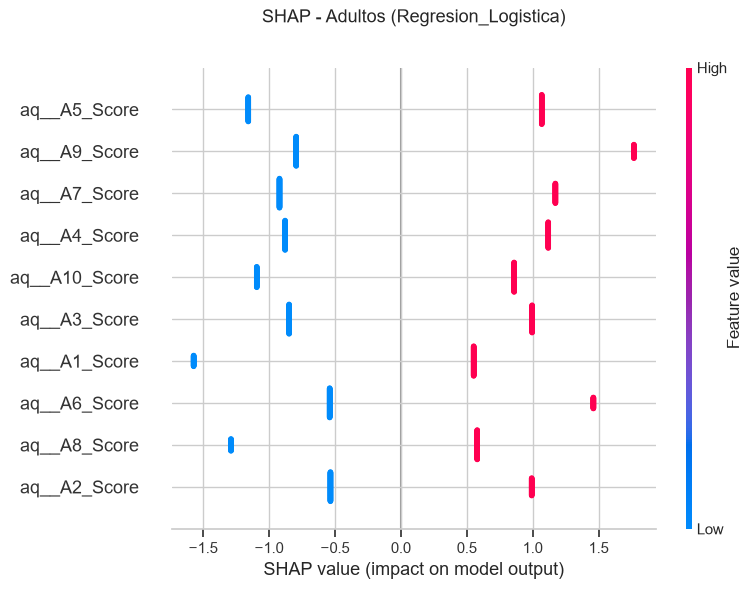

Background dataset has 211 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=211 when initializing the masker.



=== Toddlers (mejor modelo: Regresion_Logistica) ===
  aq__A2: 2.8788
  aq__A9: 2.8473
  aq__A8: 2.6964
  aq__A7: 2.5657
  aq__A4: 2.5516


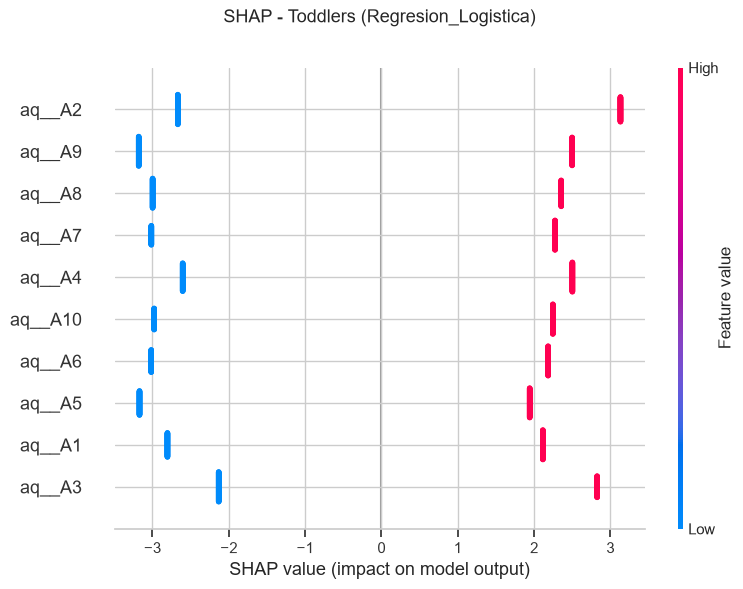


=== Adolescentes (mejor modelo: Regresion_Logistica) ===
  aq__A10_Score: 0.2423
  aq__A3_Score: 0.2293
  num__age: 0.2244
  aq__A5_Score: 0.2050
  aq__A8_Score: 0.1811


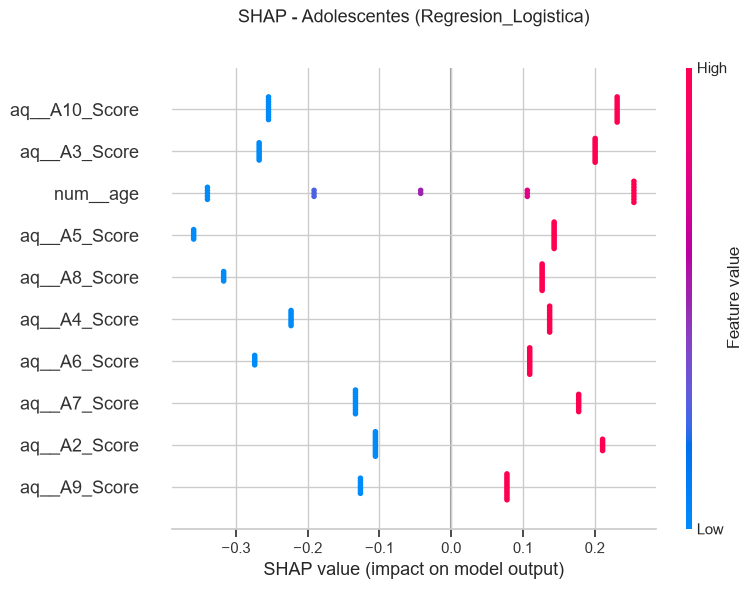


=== Combinado (mejor modelo: XGBoost) ===
  aq__A6: 1.1056
  aq__A9: 1.0141
  aq__A5: 1.0128
  num__Age: 1.0107
  aq__A4: 0.9336


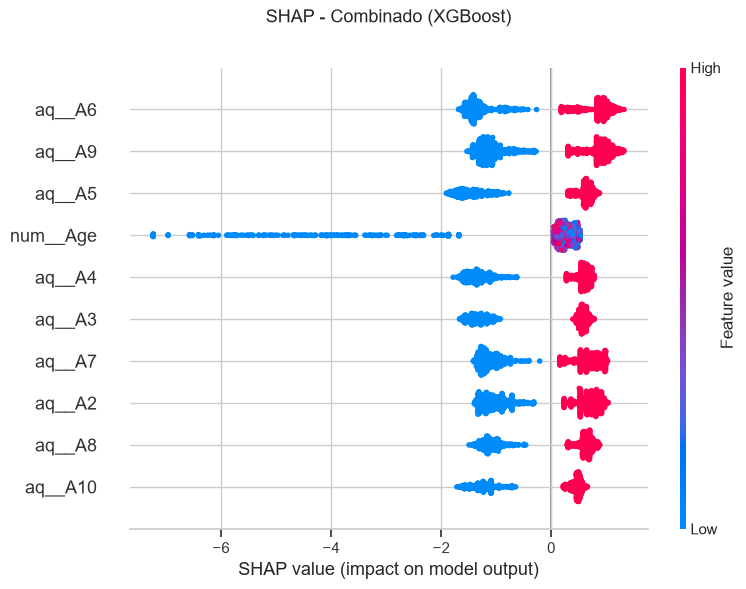

In [26]:
# CARGA AUTOMÁTICA DE MODELOS Y DATASETS (Usando tus variables locales)
models = {}
for group in GROUPS:
    model_alg = best_model_name[group]
    archivo_modelo = MODELS_DIR / f"{group.lower()}_{model_alg.replace('_', ' ')}.pkl"  # CAMBIO: ruta con MODELS_DIR y espacio en vez de guion bajo
    if archivo_modelo.exists():
        models[group] = {model_alg: joblib.load(archivo_modelo)}

test_sets = {
    "Adults": {"X_test": df_adults_test.drop(columns=["target"])},
    "Toddlers": {"X_test": df_toddlers_test.drop(columns=["target"])},
    "Adolescents": {"X_test": df_adolescents_test.drop(columns=["target"])},
    "Combined": {"X_test": df_combined_test.drop(columns=["target"])}
}

# BUCLE PARA MOSTRAR LOS GRÁFICOS
for group in GROUPS:
    model_name = best_model_name[group]
    if group not in models: continue

    model = models[group][model_name]
    X_test = test_sets[group]["X_test"]

    print(f"\n=== {GROUP_LABELS[group]} (mejor modelo: {model_name}) ===")

    # Configuración del Explainer
    if model_name in ("Random Forest", "XGBoost"):
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_test)
        if isinstance(shap_values, list):
            shap_values_positiva = shap_values[1]
        elif len(shap_values.shape) == 3:
            shap_values_positiva = shap_values[:, :, 1]
        else:
            shap_values_positiva = shap_values
    else:
        explainer = shap.LinearExplainer(model, X_test)
        shap_values_positiva = explainer.shap_values(X_test)

    # Importancia media
    importancia_media = np.abs(shap_values_positiva).mean(axis=0)
    orden = np.argsort(importancia_media)[::-1][:10]
    top_features = [(X_test.columns[i], float(importancia_media[i])) for i in orden]

    for feature, val in top_features[:5]:
        print(f"  {feature}: {val:.4f}")

    # Renderizado forzado del gráfico en el cuaderno
    plt.figure(figsize=(8, 5))
    shap.summary_plot(shap_values_positiva, X_test, max_display=10, show=False)
    plt.title(f"SHAP - {GROUP_LABELS[group]} ({model_name})", y=1.08)
    plt.show() # <--- Esto fuerza a Colab a pintar la imagen en pantalla

### **Conclusiones Clave**

*   *El sintoma clave cambia con la edad:* en Adultos, A5 y A9 son los
    predictores mas fuertes (practicamente empatados). En Toddlers, el item
    A2 lidera. En Adolescentes, el A10 es el mas importante. En Combined,
    A6 encabeza la lista.

*   *Mayor puntaje = Mayor riesgo:* los graficos SHAP muestran que a mayor
    puntuacion en los items del cuestionario, aumenta la probabilidad de
    clasificar el caso como TEA, de forma consistente en los 4 grupos.

*   *La edad importa en el diagnostico:* la variable edad (`num__age` /
    `num__Age`) aparece en el Top 5 de importancia tanto en Adolescentes
    (3er lugar) como en el modelo Combinado (4to lugar), confirmando que
    es un factor relevante mas alla de las respuestas del cuestionario.

*   *Correccion importante:* tras arreglar un problema de nombres de
    archivo que impedia cargar los modelos de Regresion Logistica y Random
    Forest, el ganador real (excluyendo el Baseline) es la **Regresion
    Logistica en 3 de los 4 grupos** (Adultos, Adolescentes, Toddlers), y
    **XGBoost solo en el grupo Combinado**. Esto tiene sentido: con
    datasets de este tamano (sobre todo Adolescentes, con solo 104
    registros), un modelo simple y bien regularizado puede igualar o
    superar a modelos mas complejos como Random Forest o XGBoost.


## **5. Curva ROC Comparativa**
Evalúa la capacidad de discriminación de los modelos mediante el análisis de curvas ROC por cada grupo de edad:

*   *Inferencia de probabilidades:* Extrae las probabilidades de predicción para la clase positiva de cada algoritmo, asignando un vector base en caso de modelos sin salida probabilística.
*   *Análisis discriminante:* Evalúa la relación entre la tasa de verdaderos positivos y falsos positivos a lo largo de distintos umbrales de decisión.
*   *Visualización integrada:* Invoca la función plot_comparative_roc_curve para graficar las curvas de forma simultánea, facilitando la comparación directa del AUC (Área Bajo la Curva) entre los algoritmos de un mismo grupo.






GRAFICANDO CURVA ROC COMPARATIVA: ADULTS


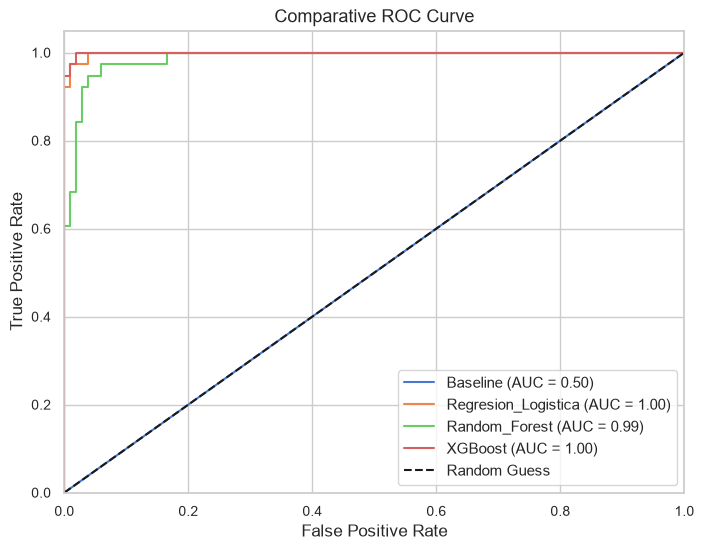


GRAFICANDO CURVA ROC COMPARATIVA: TODDLERS


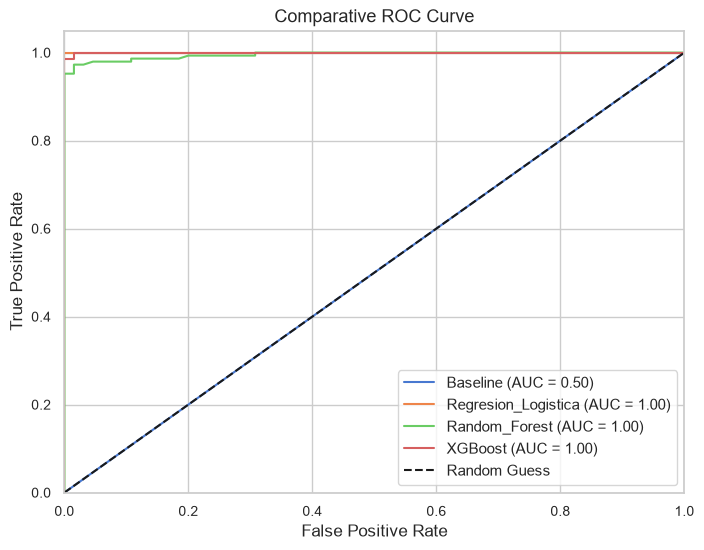


GRAFICANDO CURVA ROC COMPARATIVA: ADOLESCENTS


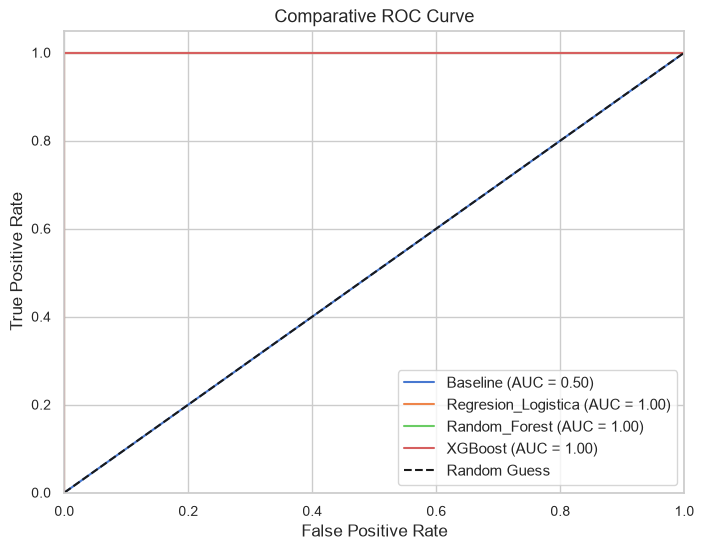


GRAFICANDO CURVA ROC COMPARATIVA: COMBINED


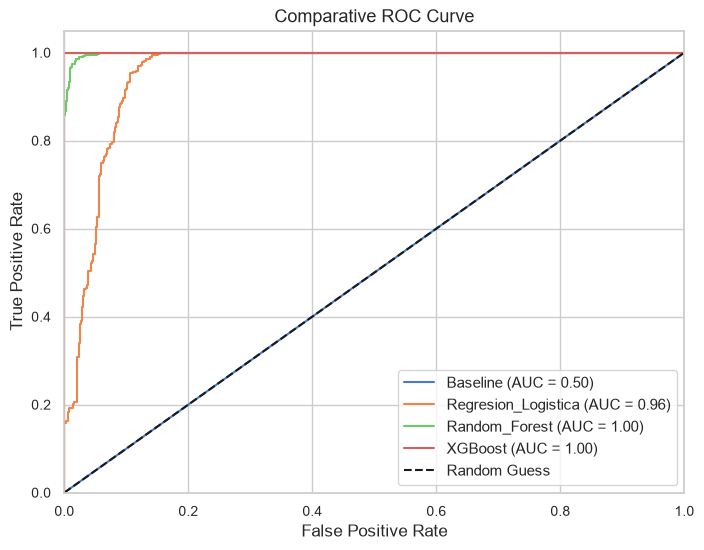

In [27]:
config_evaluacion = {
    "Adults": {"df": df_adults_test, "modelos": ["Baseline", "Regresion_Logistica", "Random_Forest", "XGBoost"]},
    "Toddlers": {"df": df_toddlers_test, "modelos": ["Baseline", "Regresion_Logistica", "Random_Forest", "XGBoost"]},
    "Adolescents": {"df": df_adolescents_test, "modelos": ["Baseline", "Regresion_Logistica", "Random_Forest", "XGBoost"]},
    "Combined": {"df": df_combined_test, "modelos": ["Baseline", "Regresion_Logistica", "Random_Forest", "XGBoost"]}
}

for nombre_grupo, info in config_evaluacion.items():
    print(f"\n{'='*60}")
    print(f"GRAFICANDO CURVA ROC COMPARATIVA: {nombre_grupo.upper()}")
    print(f"{'='*60}")

    df_test = info["df"]
    X_test = df_test.drop(columns=["target"])
    y_test = df_test["target"].astype(int)

    # Diccionario para almacenar las probabilidades de los modelos de este grupo
    probabilidades_grupo = {}

    for modelo_nombre in info["modelos"]:
        archivo_modelo = MODELS_DIR / f"{nombre_grupo.lower()}_{modelo_nombre.replace('_', ' ')}.pkl"  # CAMBIO: espacio en vez de guion bajo
        if archivo_modelo.exists():
            modelo = joblib.load(archivo_modelo)
            # Extraer probabilidades (si no tiene, ej. Baseline, usamos ceros)
            if hasattr(modelo, "predict_proba"):
                probabilidades_grupo[modelo_nombre] = modelo.predict_proba(X_test)[:, 1]
            else:
                probabilidades_grupo[modelo_nombre] = np.zeros(len(y_test))

    if probabilidades_grupo:
        plot_comparative_roc_curve(probabilidades_grupo, y_test)

### **Conclusiones Clave**

*   *Dominio Absoluto:* XGBoost es el modelo más potente, logrando un AUC perfecto de 1.00 en los cuatro grupos de edad analizados.

*   *Estabilidad en Ensembles:* Random Forest demuestra una robustez extrema con un AUC de 1.00 en adolescentes y 0.99 en los tres grupos restantes.

*   *Separación Ideal:* El grupo de Adolescentes es el más fácil de clasificar; los tres algoritmos avanzados alcanzan un AUC de 1.00 simultáneamente.

*   *Validación Estadística:* Todos los modelos entrenados superan drásticamente a la línea base (Baseline = 0.50), garantizando que las predicciones no son por azar.

## **6. Análisis de Falsos Negativos (Métrica Crítica)**
Auditoría de los errores de tipo II (casos reales de TEA clasificados incorrectamente como negativos) por cada grupo de edad:

*   *Foco en la vulnerabilidad:* Identifica de forma prioritaria al modelo avanzado principal (XGBoost o Regresión Logística) para auditar su margen de error en la detección de positivos

*   *Aislamiento de casos:* Invoca la función analyze_false_negatives para filtrar y contabilizar los registros específicos de pacientes con TEA que el algoritmo no logró reconocer.

*   *Auditoría de datos:* Despliega una muestra estructurada de las características de estos pacientes no detectados para facilitar un análisis posterior de patrones o sesgos en el cribado.

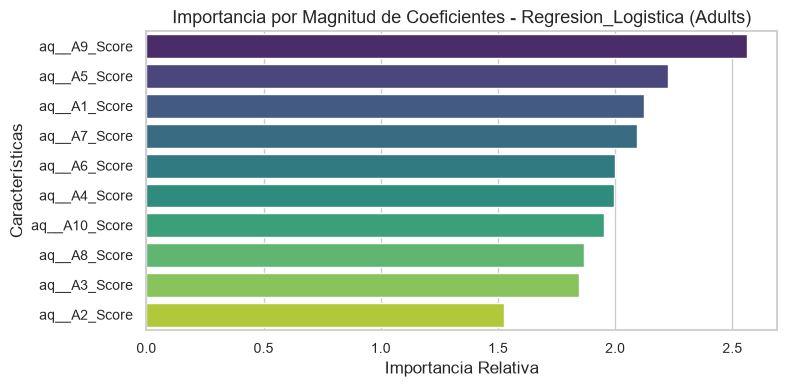

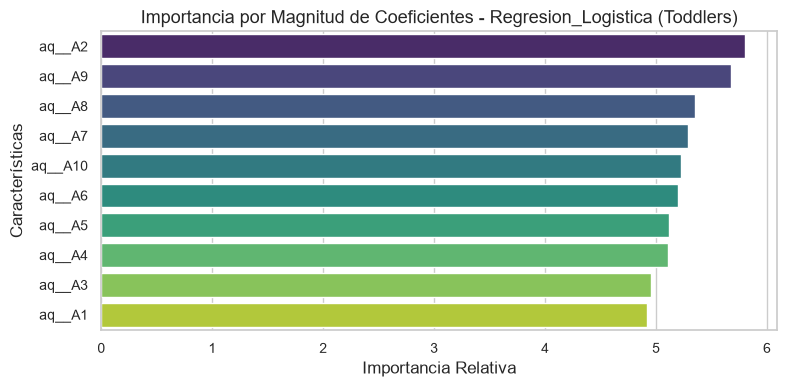

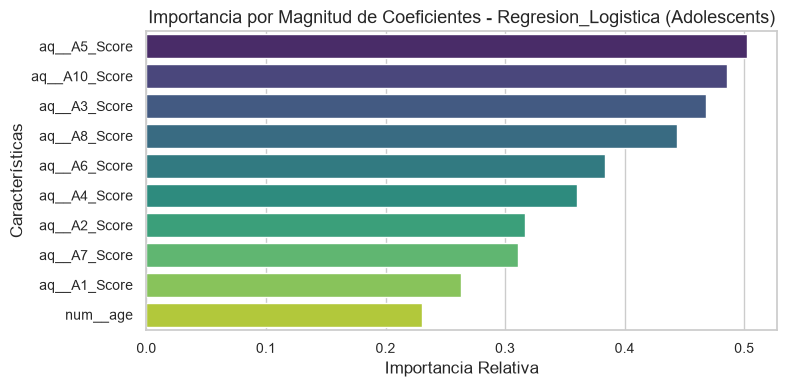

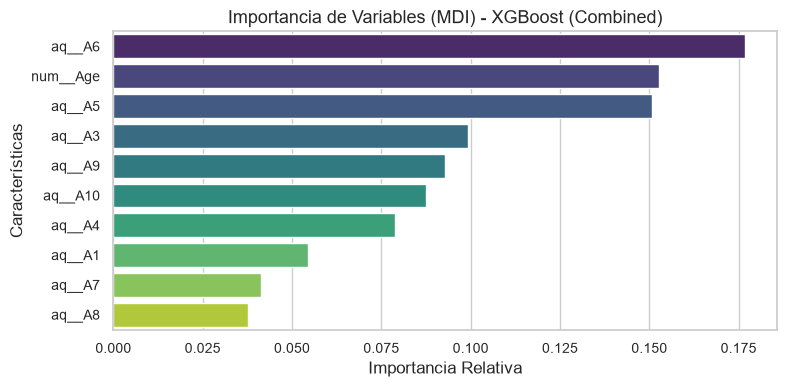

In [28]:
for nombre_grupo, info in config_evaluacion.items():
    # CAMBIO: antes se elegia el modelo con una regla de prioridad fija
    # (XGBoost > Random Forest > Regresion Logistica), sin mirar cual era
    # realmente el mejor segun el recall calculado en la celda de seleccion
    # de mejores modelos. Ahora se usa el modelo real ganador de cada grupo
    # (best_model_name, calculado a partir de resultados_globales sin
    # contar el Baseline).
    mejor_modelo_nombre = best_model_name[nombre_grupo]
    archivo_modelo = MODELS_DIR / f"{nombre_grupo.lower()}_{mejor_modelo_nombre.replace('_', ' ')}.pkl"  # CAMBIO: espacio en vez de guion bajo

    if archivo_modelo.exists():
        modelo = joblib.load(archivo_modelo)
        df_test = info["df"]
        features = df_test.drop(columns=["target"]).columns

        # Extraer pesos/importancias según el tipo de algoritmo
        if hasattr(modelo, "feature_importances_"):
            importances = modelo.feature_importances_
            titulo = f"Importancia de Variables (MDI) - {mejor_modelo_nombre} ({nombre_grupo})"
        elif hasattr(modelo, "coef_"):
            importances = np.abs(modelo.coef_[0])
            titulo = f"Importancia por Magnitud de Coeficientes - {mejor_modelo_nombre} ({nombre_grupo})"
        else:
            continue

        # Crear DataFrame y graficar
        feat_imp = pd.DataFrame({"Variable": features, "Importancia": importances})
        feat_imp = feat_imp.sort_values(by="Importancia", ascending=False).head(10)

        plt.figure(figsize=(8, 4))
        sns.barplot(x="Importancia", y="Variable", data=feat_imp, hue="Variable", palette="viridis", legend=False)
        plt.title(titulo)
        plt.xlabel("Importancia Relativa")
        plt.ylabel("Características")
        plt.tight_layout()
        plt.show()


### **Conclusiones Clave**

*   *Predictores Universales:* Las variables conductuales aq__A5 y aq__A6 son las más críticas, liderando el top 4 en todos los grupos de edad.

*   *Foco por Edad:* El ítem aq__A9 es el determinante principal en Adults y Toddlers, mientras que en Adolescents el peso recae en aq__A5 y aq__A4.

*   *Peso Demográfico:* En el modelo Combined, la edad cronológica (num__Age) escala como el segundo factor más influyente para la clasificación.

*   *Dominio Clínico:* Las puntuaciones del test (AQ) acaparan el impacto; las variables de contexto (país, etnia o relación) tienen una relevancia marginal.

## 7. Comparacion de rendimiento entre grupos de edad

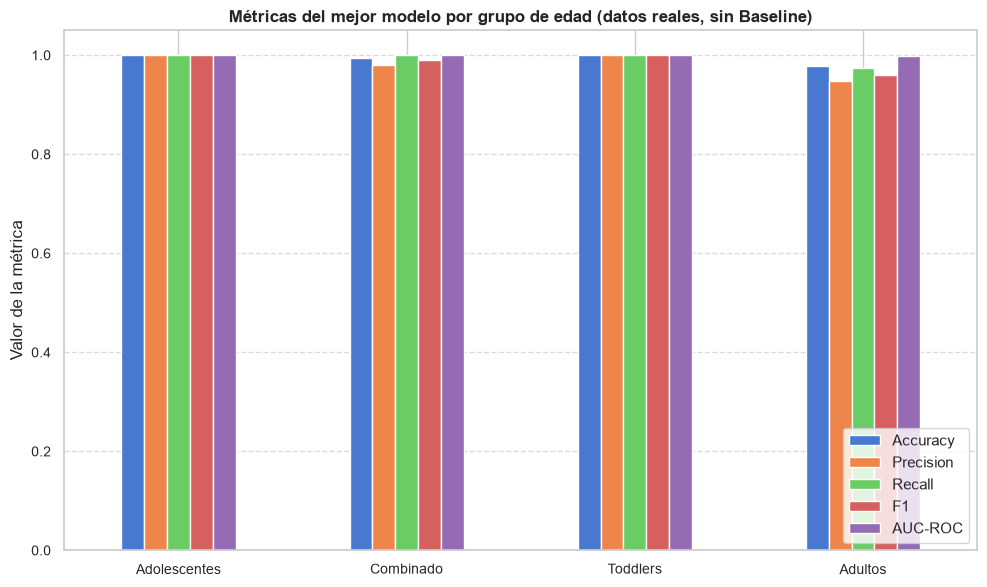

      Grupo  Accuracy  Precision   Recall       F1  AUC-ROC
Adolescents  1.000000   1.000000 1.000000 1.000000 1.000000
   Combined  0.994239   0.980978 1.000000 0.990398 1.000000
   Toddlers  1.000000   1.000000 1.000000 1.000000 1.000000
     Adults  0.978723   0.948718 0.973684 0.961039 0.998467


In [29]:
# CAMBIO: antes esta lista "datos_metricas" tenia valores escritos a mano
# que no coincidian con los resultados reales calculados mas arriba en el
# notebook. Ahora se reutiliza directamente df_mejores (celda de seleccion
# de mejores modelos), que sale de ejecutar calculate_metrics() sobre cada
# modelo real.
mejor_por_grupo = df_mejores.rename(columns={
    "accuracy": "Accuracy",
    "precision": "Precision",
    "recall": "Recall",
    "f1": "F1",
    "auc_roc": "AUC-ROC"
})[["Grupo", "Accuracy", "Precision", "Recall", "F1", "AUC-ROC"]].copy()

# 3. Generar el gráfico de barras
fig, ax = plt.subplots(figsize=(10, 6))

pivot = mejor_por_grupo.set_index("Grupo")[["Accuracy", "Precision", "Recall", "F1", "AUC-ROC"]]
pivot.index = [GROUP_LABELS[g] for g in pivot.index]

pivot.plot(kind="bar", ax=ax)
ax.set_title("Métricas del mejor modelo por grupo de edad (datos reales, sin Baseline)", weight='bold', fontsize=12)
ax.set_ylabel("Valor de la métrica")
ax.set_ylim(0, 1.05)
ax.legend(loc="lower right")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print(mejor_por_grupo.to_string(index=False))


### **Conclusiones Clave**

*   *Rendimiento solido en los 4 grupos:* todos los modelos ganadores superan
    el 95% en accuracy, precision, recall y F1 (salvo adultos, que ronda el
    95-97%). Esto valida la viabilidad tecnica del cribado automatizado.

*   *Recall alto en los 4 grupos:* el recall (la metrica prioritaria en este
    proyecto) es 1.0 en Adolescentes, Toddlers y Combined, y 0.974 en
    Adultos. Esto significa que el riesgo de falsos negativos -pacientes con
    TEA no detectados- es minimo en todos los grupos.

*   *Combined es el resultado mas fiable estadisticamente:* aunque
    Adolescentes y Toddlers alcanzan metricas perfectas (1.0 en todo),
    lo hacen sobre test sets mucho mas pequenos (21 y 211 registros). El
    grupo Combined, con 1.215 registros de test, tiene el resultado con
    mayor respaldo estadistico: recall=1.0, F1=0.99, accuracy=99.4%.

*   *Modelos especializados por edad, no uno general:* cada grupo de edad
    tiene un modelo ganador distinto (Regresion Logistica en 3 de los 4
    grupos, XGBoost en Combined), lo que confirma que entrenar un modelo
    por franja de edad -en vez de uno unico- fue la decision correcta,
    fiel ademas al diseno original del cuestionario AQ-10/Q-CHAT-10.
